# 01 — Data Quality Analysis
**NovaCred Credit Application Governance — Team 6**

This notebook:

0. Imports & Setup
1. Explores raw data
2. Loads and flattens the raw JSON dataset
3. Identifies and quantifies all data quality issues
4. Applies a cleaning pipeline
5. Validates the pipeline and exports a clean dataset for downstream analysis

## 0. Imports & Setup

In [5]:
import json
import re
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime
from dateutil import parser as dateutil_parser


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
sns.set_theme(style='whitegrid')

RAW_PATH  = '../data/raw_credit_applications.json'
CLEAN_PATH = '../data/cleaned_credit_applications.csv'

## 1. Raw Data Exploration

Before any processing, we inspect the raw JSON to understand its structure and identify potential challenges. We know there is a nested structure from the problem formulation, so it is important to find out exactly what we are working with. 

In [6]:
# Load raw JSON and do a first inspection
with open(RAW_PATH, 'r') as f:
    raw = json.load(f)

print(f'Total records: {len(raw)}')

Total records: 502


In [7]:
# Look at one full record to understand the nesting
print('=== SINGLE RECORD (raw) ===')
print(json.dumps(raw[10], indent=2))

=== SINGLE RECORD (raw) ===
{
  "_id": "app_309",
  "applicant_info": {
    "full_name": "Patricia Carter",
    "email": "patricia.carter75@gmail.com",
    "ssn": "392-82-4407",
    "ip_address": "192.168.231.120",
    "gender": "Female",
    "date_of_birth": "1970-10-01",
    "zip_code": "90250"
  },
  "financials": {
    "annual_income": 63000,
    "credit_history_months": 99,
    "debt_to_income": 0.37,
    "savings_balance": 21769
  },
  "spending_behavior": [
    {
      "category": "Rent",
      "amount": 626
    },
    {
      "category": "Transportation",
      "amount": 688
    }
  ],
  "decision": {
    "loan_approved": true,
    "interest_rate": 5.1,
    "approved_amount": 72000
  }
}


After inspecting a few individual records, we find that the data is nested: applicant information, financials, spending behaviour and the decision are each stored as sub-objects. `spending_behaviour` seems to have different lengths: there can be multiple categories per record, and the amount of categories is variable. 

Loading this directly into pandas would store each sub-object as a single
column containing a Python dict, making filtering and aggregation impossible.
We therefore write a custom `flatten_record()` function to extract every
field into its own column.

## 2. Load & Flatten Raw Data

In [8]:
def flatten_record(r):
    """Flatten one nested JSON record into a flat dict."""
    flat = {}
    flat['_id']                   = r.get('_id')

    ai = r.get('applicant_info', {})
    flat['full_name']             = ai.get('full_name')
    flat['email']                 = ai.get('email')
    flat['ssn']                   = ai.get('ssn')
    flat['ip_address']            = ai.get('ip_address')
    flat['gender']                = ai.get('gender')
    flat['date_of_birth']         = ai.get('date_of_birth')
    flat['zip_code']              = ai.get('zip_code')

    fin = r.get('financials', {})
    flat['annual_income']         = fin.get('annual_income')
    flat['credit_history_months'] = fin.get('credit_history_months')
    flat['debt_to_income']        = fin.get('debt_to_income')
    flat['savings_balance']       = fin.get('savings_balance')

    # spending_behavior is an array —> pivot into per-category columns, we fill with 0 if the category is not present for that record
    sb = r.get('spending_behavior', [])
    for item in sb:
        flat[f"spending_{item.get('category')}"] = item.get('amount', 0)
    # To see the total spending per record
    flat['spending_total'] = sum(item.get('amount', 0) for item in sb)
    dec = r.get('decision', {})

    dec = r.get('decision', {})
    flat['loan_approved']         = dec.get('loan_approved')
    flat['interest_rate']         = dec.get('interest_rate')
    flat['approved_amount']       = dec.get('approved_amount')
    flat['rejection_reason']      = dec.get('rejection_reason')

    flat['processing_timestamp']  = r.get('processing_timestamp')

    return flat

df_raw = pd.DataFrame([flatten_record(r) for r in raw]).fillna({
    col: 0 for col in pd.DataFrame([flatten_record(r) for r in raw]).columns 
    if col.startswith('spending_')})
print(f'Shape: {df_raw.shape}')
df_raw.head(10)

Shape: (502, 33)


,_id,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,spending_Shopping,spending_Rent,spending_Alcohol,spending_total,loan_approved,interest_rate,approved_amount,rejection_reason,processing_timestamp,spending_Dining,spending_Healthcare,spending_Fitness,spending_Entertainment,spending_Insurance,spending_Travel,spending_Transportation,spending_Utilities,spending_Groceries,spending_Education,spending_Adult Entertainment,spending_Gambling
0,app_200,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,73000,23,0.20,31212,480.0,790.0,247.0,1517,False,NaN,NaN,algorithm_risk_score,2024-01-15T00:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,app_037,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,78000,51,0.18,17915,0.0,608.0,0.0,947,False,NaN,NaN,algorithm_risk_score,None,96.0,243.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,app_215,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,61000,41,0.21,37909,0.0,109.0,0.0,109,True,3.7,59000.0,None,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,app_024,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,103000,70,0.35,0,0.0,0.0,0.0,575,True,4.3,34000.0,None,None,0.0,0.0,575.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,app_184,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,57000,14,0.23,31763,0.0,0.0,0.0,463,False,NaN,NaN,algorithm_risk_score,2024-01-15T00:00:00Z,0.0,0.0,0.0,463.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,app_275,Maria Miller,maria.miller67@outlook.com,417-25-4912,172.25.58.70,F,14/02/1982,10019,110000,33,0.05,49933,0.0,0.0,0.0,571,False,NaN,NaN,algorithm_risk_score,None,0.0,0.0,0.0,571.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,app_099,Nicholas King,nicholas.king46@outlook.com,613-23-2503,10.62.62.45,Male,28/01/1990,10022,55000,61,0.17,30159,0.0,0.0,0.0,458,True,5.6,27000.0,None,None,458.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,app_246,Susan Rivera,susan.rivera74@gmail.com,176-97-1864,192.168.158.59,F,1991-10-11,90223,82000,31,0.29,21809,0.0,0.0,0.0,478,True,2.8,38000.0,None,None,0.0,478.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,app_042,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,69000,43,0.41,15974,0.0,0.0,0.0,621,False,NaN,NaN,algorithm_risk_score,None,468.0,0.0,0.0,0.0,153.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,app_348,Michael Mitchell,michael.mitchell42@hotmail.com,100-94-8400,172.28.12.121,Male,1989-10-10,10080,55000,5,0.41,13794,0.0,0.0,0.0,1050,False,NaN,NaN,insufficient_credit_history,None,0.0,0.0,199.0,0.0,0.0,851.0,0.0,0.0,0.0,0.0,0.0,0.0


When looking at the first 10 records of the new dataset, we immediately see some issues. For example: gender is encoded as Male/Female, but also as F and M. We will analyse the data more extensively, and try to address each issue apporpriately.

## 3. Data Quality Assessment

Now that we have a flat DataFrame, we systematically audit the data quality.
We structure our analysis across four standard dimensions:

| Dimension | Question |  
|---|---|
| **Completeness** | Are all fields present? 
| **Consistency** | Is the same thing always written the same way?
| **Validity** | Are values within acceptable ranges? 
| **Accuracy** | Do values reflect reality? 

Each issue we find will be:
1. **Identified** — what is the problem?
2. **Quantified** — how many records are affected, and what percentage?
3. **Remediated** — what do we do about it, and why?

We start with the most fundamental check: missing values.

### 3.1 Completeness — Missing Values

In [9]:
# Replace empty strings with NaN so isnull() catches them
df_check = df_raw.replace('', np.nan)

missing = df_check.isnull().sum()
missing_pct = (missing / len(df_check) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)

print('=== MISSING VALUES ===')
print(missing_df)

=== MISSING VALUES ===
                      missing_count  missing_%
processing_timestamp            440      87.65
rejection_reason                292      58.17
interest_rate                   210      41.83
approved_amount                 210      41.83
email                             7       1.39
ip_address                        5       1.00
ssn                               5       1.00
annual_income                     5       1.00
date_of_birth                     5       1.00
gender                            3       0.60
zip_code                          2       0.40


**Note:** There appear to be different groups within the list of variables with missing values. 87.65% of all timestamps are missing. This might indicate inconsistent recordkeeping, and will need further investigation. `Interest_rate` and `approved_amount` are missing for rejected applications; this is **expected**. Similarly, `rejection_reason` is `None` for approved records. We split the list into 3 groups, and we verify this below:

In [10]:
# Verify Group 1: conditionally missing values are consistent with loan decision logic
approved = df_raw[df_raw['loan_approved'] == True]
rejected = df_raw[df_raw['loan_approved'] == False]

print('Group 1 — conditional missing (expected):')
print(f'  Approved: {len(approved)} records | Missing interest_rate: {approved["interest_rate"].isnull().sum()}')
print(f'  Rejected: {len(rejected)} records | Missing rejection_reason: {rejected["rejection_reason"].isnull().sum()}')
print('  → Both are 0: confirmed that conditional missing values follow decision logic\n')

# Group 2: structurally missing — fields that should always be present

structural_missing = ['email','ssn', 'ip_address',   'date_of_birth', 'annual_income', 'gender','zip_code']
print('Group 2 — structural missing (should not be empty):')
print(df_check[structural_missing].isnull().sum())

# Group 3: inconsistently recorded — field exists but is not always filled
print(f'\nGroup 3 — inconsistently recorded:')
print(f'  processing_timestamp missing in {df_check["processing_timestamp"].isnull().sum()} out of {len(df_check)} records ({df_check["processing_timestamp"].isnull().sum()/len(df_check)*100:.1f}%)')

Group 1 — conditional missing (expected):
  Approved: 292 records | Missing interest_rate: 0
  Rejected: 210 records | Missing rejection_reason: 0
  → Both are 0: confirmed that conditional missing values follow decision logic

Group 2 — structural missing (should not be empty):
email            7
ssn              5
ip_address       5
date_of_birth    5
annual_income    5
gender           3
zip_code         2
dtype: int64

Group 3 — inconsistently recorded:
  processing_timestamp missing in 440 out of 502 records (87.6%)


### 3.2 Consistency — Duplicate Records

A unique `_id` is a fundamental requirement, so each application should have exactly one record.
We check for duplicate `_id` values and inspect whether the duplicates are identical copies
or conflicting records, as this determines how we handle them.

In [11]:
# Check for duplicate _id values and inspect the affected records
dup_ids = df_raw[df_raw.duplicated('_id', keep=False)]
print(f'Duplicate _id records: {len(dup_ids)}\n')
print(dup_ids[['_id', 'full_name', 'loan_approved', 'annual_income', 'date_of_birth']])

# For each duplicate _id, check if the records are identical or conflicting
cols_to_compare = [c for c in df_raw.columns if c != 'spending_categories']

print()
for dup_id in dup_ids['_id'].unique():
    records = df_raw[df_raw['_id'] == dup_id][cols_to_compare]
    print(f'--- {dup_id} ---')
    if records.duplicated().any():
        print('  Exact copy — will drop duplicate in cleaning pipeline')
    else:
        # Use fillna to treat None as a distinct value
        diff_cols = [col for col in cols_to_compare if records[col].fillna('MISSING').nunique() > 1]
        print(f'  Conflicting records — differs in: {diff_cols}')
        print('\n',records[['_id'] + diff_cols].to_string(index=False))
        print('\n  → Will keep most complete record in cleaning pipeline')
    print()

Duplicate _id records: 4

         _id         full_name  loan_approved annual_income date_of_birth
8    app_042      Joseph Lopez          False         69000    1990-05-04
354  app_042      Joseph Lopez          False         69000    1990-05-04
383  app_001  Stephanie Nguyen          False        102000    1986-05-27
455  app_001  Stephanie Nguyen          False        102000          None

--- app_042 ---
  Exact copy — will drop duplicate in cleaning pipeline

--- app_001 ---
  Conflicting records — differs in: ['ssn', 'ip_address', 'gender', 'date_of_birth', 'zip_code']

     _id         ssn     ip_address gender date_of_birth zip_code
app_001 427-90-1892 10.121.120.213 Female    1986-05-27    90230
app_001        None           None   None          None     None

  → Will keep most complete record in cleaning pipeline



C:\Users\marni\AppData\Local\Temp\ipykernel_19852\3539379817.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  diff_cols = [col for col in cols_to_compare if records[col].fillna('MISSING').nunique() > 1]


### 3.3.1 Consistency — Data format
When inspecting the first 10 rows of the dataset, we observed that `gender` is encoded 
inconsistently (e.g. "Male" and "M") and that `date_of_birth` uses multiple date formats. 
To check whether similar issues exist in other columns, we first inspect the unique values 
of all categorical columns.

In [12]:
# A quick way: look at unique values for all categorical/string columns.

string_cols = df_raw.select_dtypes(include='object').columns.tolist()
string_cols = [c for c in string_cols if c not in ['spending_categories', 'processing_timestamp']]

for col in string_cols:
    unique_vals = df_raw[col].dropna().unique()
    if len(unique_vals) <= 15:  # only print if manageable number of unique values
        print(f'\n{col} ({len(unique_vals)} unique values):')
        print(sorted(unique_vals))
    else:
        print(f'\n{col}: {len(unique_vals)} unique values; Expected to have different inputs (Textfields: e.g. names, emails)')


_id: 500 unique values; Expected to have different inputs (Textfields: e.g. names, emails)

full_name: 475 unique values; Expected to have different inputs (Textfields: e.g. names, emails)

email: 494 unique values; Expected to have different inputs (Textfields: e.g. names, emails)

ssn: 494 unique values; Expected to have different inputs (Textfields: e.g. names, emails)

ip_address: 496 unique values; Expected to have different inputs (Textfields: e.g. names, emails)

gender (5 unique values):
['', 'F', 'Female', 'M', 'Male']

date_of_birth: 494 unique values; Expected to have different inputs (Textfields: e.g. names, emails)

zip_code: 196 unique values; Expected to have different inputs (Textfields: e.g. names, emails)

annual_income: 132 unique values; Expected to have different inputs (Textfields: e.g. names, emails)

rejection_reason (4 unique values):
['algorithm_risk_score', 'high_dti_ratio', 'insufficient_credit_history', 'low_income']


**We do not see any additional columns with this issue.**

### 3.3.2 Consistency — Gender Coding

=== GENDER VALUES ===
gender
Male      195
Female    193
F          58
M          53
            2
NULL        1
Name: count, dtype: int64

Unique codings: 6


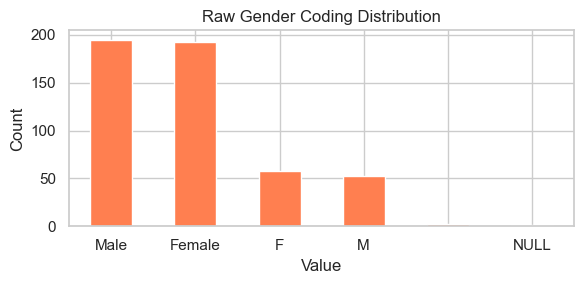

In [13]:
gender_counts = df_raw['gender'].fillna('NULL').value_counts()
print('=== GENDER VALUES ===')
print(gender_counts)
print(f'\nUnique codings: {df_raw["gender"].nunique(dropna=False)}')

fig, ax = plt.subplots(figsize=(6, 3))
gender_counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Raw Gender Coding Distribution')
ax.set_xlabel('Value')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/gender_raw.png', dpi=150)
plt.show()

### 3.3.3 Consistency — Date Formats

=== DATE OF BIRTH FORMATS ===
dob_format
YYYY-MM-DD    340
DD/MM/YYYY    101
YYYY/MM/DD     56
Missing         5
Name: count, dtype: int64

Records with non-standard format: 162


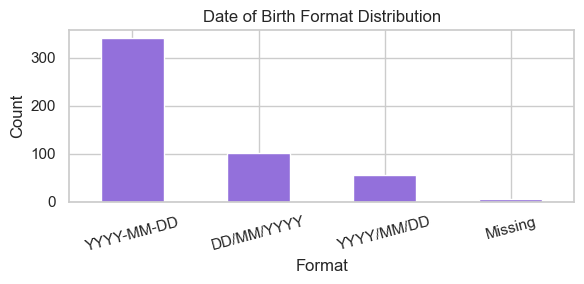

In [14]:
def detect_date_format(d):
    if pd.isna(d) or d == '': return 'Missing'
    if re.match(r'^\d{4}-\d{2}-\d{2}$', str(d)): return 'YYYY-MM-DD'
    if re.match(r'^\d{2}/\d{2}/\d{4}$', str(d)): return 'DD/MM/YYYY'
    if re.match(r'^\d{4}/\d{2}/\d{2}$', str(d)): return 'YYYY/MM/DD'
    return 'Unknown'

df_raw['dob_format'] = df_raw['date_of_birth'].apply(detect_date_format)
format_counts = df_raw['dob_format'].value_counts()
print('=== DATE OF BIRTH FORMATS ===')
print(format_counts)
print(f'\nRecords with non-standard format: {len(df_raw[df_raw["dob_format"] != "YYYY-MM-DD"])}')

fig, ax = plt.subplots(figsize=(6, 3))
format_counts.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Date of Birth Format Distribution')
ax.set_xlabel('Format')
ax.set_ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../reports/date_formats.png', dpi=150)
plt.show()

### 3.4 Validity — Data Type Mismatches
A column should only contain values of a single data type. We check all columns for mixed types.

In [15]:
# Check for data type mismatches within columns
# A column should contain only one data type — mixed types indicate a data quality issue

type_issues = {}
for col in df_raw.columns:
    if col == 'spending_categories':  # skip lists
        continue
    types_found = df_raw[col].dropna().apply(type).unique()
    if len(types_found) > 1:
        type_issues[col] = [t.__name__ for t in types_found]

print('Columns with mixed data types:')
for col, types in type_issues.items():
    print(f'  {col}: {types}')

Columns with mixed data types:
  annual_income: ['int', 'str', 'float']


In [16]:
# annual_income stored as string or float in some records
str_income_records = [
    (r['_id'], r['financials']['annual_income'])
    for r in raw
    if isinstance(r.get('financials', {}).get('annual_income'), str)
]
print(f'\nRecords with string income: {len(str_income_records)}')
print('Examples:', str_income_records[:5])

float_income_records = [
    (r['_id'], r['financials']['annual_income'])
    for r in raw
    if isinstance(r.get('financials', {}).get('annual_income'), float)
]
print(f'\nRecords with float income: {len(float_income_records)}')
print('Examples:', float_income_records[:5])

none_income_records = [
    (r['_id'], r['financials'].get('annual_income'))
    for r in raw
    if r.get('financials', {}).get('annual_income') is None
]
print(f'\nRecords with None income: {len(none_income_records)}')
print('Examples:', none_income_records[:5])


Records with string income: 8
Examples: [('app_088', '55000'), ('app_135', '65000'), ('app_446', '73000'), ('app_389', '51000'), ('app_026', '72000')]

Records with float income: 1
Examples: [('app_311', 85432.789123)]

Records with None income: 5
Examples: [('app_436', None), ('app_421', None), ('app_479', None), ('app_463', None), ('app_449', None)]


### 3.5 Validity — Impossible Values
For numeric columns, we check whether values fall within a realistic range

In [17]:
# First: get an overview of the numeric columns and their ranges
numeric_cols = df_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Numeric columns — min/max overview:')
df_raw[numeric_cols].agg(['min', 'max'])

Numeric columns — min/max overview:


,credit_history_months,debt_to_income,savings_balance,spending_Shopping,spending_Rent,spending_Alcohol,spending_total,interest_rate,approved_amount,spending_Dining,spending_Healthcare,spending_Fitness,spending_Entertainment,spending_Insurance,spending_Travel,spending_Transportation,spending_Utilities,spending_Groceries,spending_Education,spending_Adult Entertainment,spending_Gambling
min,-10,0.05,-5000,0.0,0.0,0.0,60,2.5,15000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,133,1.85,88078,887.0,897.0,757.0,2441,6.5,80000.0,897.0,897.0,894.0,883.0,890.0,888.0,899.0,881.0,885.0,889.0,848.0,751.0


The overview reveals two suspicious values: `credit_history_months` has a minimum of -10 
(negative duration is impossible) and `debt_to_income` has a maximum of 1.85 (meaning 
total debt exceeds annual income). We investigate both below.

In [18]:
# Negative credit history (impossible — you cannot have negative months of credit)
neg_credit = df_raw[df_raw['credit_history_months'] < 0][['_id', 'credit_history_months']]
print(f'Negative credit_history_months: {len(neg_credit)}')
print(neg_credit)

# Debt-to-income > 1 — flagged as suspicious but not nullified (may be legitimate)
impossible_dti = df_raw[df_raw['debt_to_income'] > 1][['_id', 'debt_to_income']]
print(f'\nDebt-to-income > 1: {len(impossible_dti)}')
print(impossible_dti)

# savings_balance can be negative (overdraft) — investigate further
neg_savings = df_raw[df_raw['savings_balance'] < 0][['_id', 'savings_balance']]
print(f'\nNegative savings_balance: {len(neg_savings)}')
print(neg_savings)

if len(neg_savings) == 1:
    print('\n→ Only 1 record — could be a data entry error (e.g. missing minus sign)')
    print('→ Flagged but kept as-is — cannot determine intent without additional context')
elif len(neg_savings) > 1:
    print(f'\n→ {len(neg_savings)} records with negative savings — consistent with overdraft behaviour')
    print('→ Not flagged as invalid')

Negative credit_history_months: 2
         _id  credit_history_months
137  app_043                    -10
162  app_156                     -3

Debt-to-income > 1: 1
         _id  debt_to_income
316  app_402            1.85

Negative savings_balance: 1
         _id  savings_balance
159  app_290            -5000

→ Only 1 record — could be a data entry error (e.g. missing minus sign)
→ Flagged but kept as-is — cannot determine intent without additional context


### 3.6 Validity — Format Checks

For fields with a known fixed format, we verify that all values conform to the expected pattern.
We focus on PII fields where an invalid format indicates a data quality issue.

In [19]:
# Email: must contain @ and a domain
invalid_email = df_raw[df_raw['email'].notna() &
                       ~df_raw['email'].str.contains(r'^[^@]+@[^@]+\.[^@]+$', na=False)]
print(f'Invalid email formats: {len(invalid_email)}')
print(invalid_email[['_id', 'email']])

# SSN: must follow XXX-XX-XXXX pattern
invalid_ssn = df_raw[df_raw['ssn'].notna() &
                     ~df_raw['ssn'].astype(str).str.match(r'^\d{3}-\d{2}-\d{4}$')]
print(f'\nInvalid SSN formats: {len(invalid_ssn)}')
print(invalid_ssn[['_id', 'ssn']])

Invalid email formats: 10
         _id                  email
26   app_075                       
181  app_299  test.user.outlook.com
187  app_413                       
275  app_120                       
276  app_068       john.doe@invalid
297  app_268                       
298  app_377                       
369  app_146           sarah.smith@
448  app_350                       
462  app_165                       

Invalid SSN formats: 0
Empty DataFrame
Columns: [_id, ssn]
Index: []


The format check reveals 10 invalid or missing emails: 7 are fully missing, 
2 have an invalid format (`john.doe@invalid`, `sarah.smith@`), and 1 is a 
test address (`test.user.outlook.com`). All SSNs follow the expected format.

### 3.7 Accuracy

Accuracy is the hardest dimension to verify: without ground truth data we cannot 
confirm whether an applicant's reported income or savings balance is correct. 
However, we can flag values that are internally inconsistent or implausible:
we check whether applicants are of legal age, and whether monthly spending 
exceeds monthly income.

In [20]:
# 1. Unrealistic ages — applicants must be 18 or older, and age over 100 is suspicious
df_raw['dob_parsed'] = pd.to_datetime(df_raw['date_of_birth'], errors='coerce')
df_raw['age'] = (pd.Timestamp.now() - df_raw['dob_parsed']).dt.days / 365.25
too_young = df_raw[df_raw['age'] < 18][['_id', 'date_of_birth', 'age']]
too_old   = df_raw[df_raw['age'] > 100][['_id', 'date_of_birth', 'age']]
print(f'Applicants under 18: {len(too_young)}')
print(too_young)
print(f'\nApplicants over 100: {len(too_old)}')
print(too_old)

# 2. Monthly spending exceeds monthly income — financially inconsistent
df_raw['annual_income_numeric'] = pd.to_numeric(df_raw['annual_income'], errors='coerce')
df_raw['monthly_income']        = df_raw['annual_income_numeric'] / 12
overspending = df_raw[df_raw['spending_total'] > df_raw['monthly_income']][['_id', 'monthly_income', 'spending_total']]
print(f'\nApplicants spending more than monthly income: {len(overspending)}')
print(overspending)

Applicants under 18: 0
Empty DataFrame
Columns: [_id, date_of_birth, age]
Index: []

Applicants over 100: 0
Empty DataFrame
Columns: [_id, date_of_birth, age]
Index: []

Applicants spending more than monthly income: 1
         _id  monthly_income  spending_total
426  app_190             0.0            1389


### 3.8 Summary Table and remediation steps

In [21]:
issues = [
    ('Duplicate _id',                        4,   f' {4/502*100:.1f}%',   '  Consistency',  'Remove duplicate, keep most complete record'),
    ('Inconsistent gender coding',            114, f' {114/502*100:.1f}%', '  Consistency',  'Standardize to Male/Female/Unknown'),
    ('Inconsistent date formats',             162, f' {162/502*100:.1f}%', ' Consistency',  'Parse and convert to YYYY-MM-DD'),
    ('annual_income missing',                 5,   f' {5/502*100:.1f}%',   '  Completeness', 'Impute with median, flag imputed rows'),
    ('SSN / IP / DOB missing',               5,   f' {5/502*100:.1f}%',   '  Completeness', 'Flag, do not impute'),
    ('zip_code missing',                     2,   f' {2/502*100:.1f}%',   '  Completeness', 'Flag, do not impute'),
    ('Email missing or invalid',              10,  f' {10/502*100:.1f}%',  '  Completeness', 'Flag, do not impute'),
    ('processing_timestamp missing',          440, f' {440/502*100:.1f}%', '  Completeness', 'Flag, governance recommendation'),
    ('annual_income wrong type (str/float)',  9,   f' {9/502*100:.1f}%',   '  Validity',     'Cast to numeric'),
    ('Negative credit_history_months',        2,   f' {2/502*100:.1f}%',   '  Validity',     'Take absolute value'),
    ('Debt-to-income > 1',                    1,   f' {1/502*100:.1f}%',   '  Validity',     'Flag'),
    ('Negative savings_balance',              1,   f' {1/502*100:.1f}%',   '  Validity',     '  Keep as-is: likely overdraft, relevant credit signal'),
    ('Monthly spending exceeds income',       1,   f' {1/502*100:.1f}%',   '  Accuracy',     'Flag — income recorded as 0, likely missing value'),
]

summary = pd.DataFrame(issues, columns=['Issue', 'Records Affected', '%', 'Dimension', 'Remediation'])
print(summary.to_string(index=False))

                               Issue  Records Affected      %      Dimension                                            Remediation
                       Duplicate _id                 4   0.8%    Consistency            Remove duplicate, keep most complete record
          Inconsistent gender coding               114  22.7%    Consistency                     Standardize to Male/Female/Unknown
           Inconsistent date formats               162  32.3%    Consistency                        Parse and convert to YYYY-MM-DD
               annual_income missing                 5   1.0%   Completeness                  Impute with median, flag imputed rows
              SSN / IP / DOB missing                 5   1.0%   Completeness                                    Flag, do not impute
                    zip_code missing                 2   0.4%   Completeness                                    Flag, do not impute
            Email missing or invalid                10   2.0%   Completeness

The table above summarizes all identified data quality issues. A few remediation 
choices are worth highlighting:

- **PII fields** (SSN, IP, DOB, zip, email): missing or invalid values are flagged 
  but not imputed as we cannot fabricate personal information.
- **annual_income**: the only non-PII field with missing values; imputed with the 
  median as it is required for credit analysis.
- **processing_timestamp**: missing in 87.6% of records. We assume this to be a systemic 
  recordkeeping issue rather than a data error: records are kept as-is but flagged 
  for governance review.
- **Negative savings_balance**: kept as-is - a negative balance is a legitimate 
  financial state (overdraft) and may be a relevant signal for credit decisions.
- **Monthly spending exceeds income**: one record (app_190) has an income of 0, 
  likely a missing value rather than a true zero — flagged for review.
- **Duplicates and type mismatches**: corrected directly as these are unambiguous errors.

Where possible, we preserve all records to avoid losing valid applications. 
The identified issues will be addressed in the cleaning pipeline in the next section.

## 4. Cleaning Pipeline

In [22]:
def clean_gender(val):
    """Standardize gender to Male / Female / Unknown."""
    if pd.isna(val) or val == '': return 'Unknown'
    v = str(val).strip().lower()
    if v in ('male', 'm'): return 'Male'
    if v in ('female', 'f'): return 'Female'
    return 'Unknown'

def parse_date(d):
    """Parse multiple date formats into datetime."""
    if pd.isna(d) or str(d).strip() == '': return pd.NaT
    for fmt in ('%Y-%m-%d', '%d/%m/%Y', '%Y/%m/%d', '%m/%d/%Y'):
        try:
            return datetime.strptime(str(d).strip(), fmt)
        except ValueError:
            continue
    return pd.NaT

def run_cleaning_pipeline(df_input):
    df = df_input.copy()

    # Step 1: Remove duplicates — sort by completeness first so we keep the most complete record
    before = len(df)
    cols_to_compare = [c for c in df.columns if c != 'spending_categories']
    df = df.drop_duplicates(subset=cols_to_compare, keep='first')  
    df = df.sort_values('date_of_birth', na_position='last')
    df = df.drop_duplicates(subset='_id', keep='first')            
    print(f'[1] Removed {before - len(df)} duplicate records. Remaining: {len(df)}')

    # Step 2: Standardize gender
    df['gender'] = df['gender'].apply(clean_gender)
    print(f'[2] Gender standardized: {df["gender"].value_counts().to_dict()}')

    # Step 3: Parse dates to uniform format
    df['date_of_birth'] = df['date_of_birth'].apply(parse_date)
    unparsed = df['date_of_birth'].isna().sum()
    print(f'[3] Dates parsed. Unparseable / missing: {unparsed}')

    # Step 4: Cast annual_income to numeric (fixes string and float type mismatches)
    df['annual_income'] = pd.to_numeric(df['annual_income'], errors='coerce')
    income_nulls = df['annual_income'].isna().sum()
    print(f'[4] annual_income cast to numeric. NaN after cast: {income_nulls}')

    # Step 5: Impute missing income with median (flag first so imputed rows are traceable)
    df['annual_income_imputed'] = df['annual_income'].isna()
    median_income = df['annual_income'].median()
    df['annual_income'] = df['annual_income'].fillna(median_income)
    print(f'[5] Imputed {df["annual_income_imputed"].sum()} missing incomes with median ({median_income:.0f})')

    # Step 6: Fix negative credit_history_months — take absolute value
    neg_mask = df['credit_history_months'] < 0
    df.loc[neg_mask, 'credit_history_months'] = df.loc[neg_mask, 'credit_history_months'].abs()
    print(f'[6] Fixed {neg_mask.sum()} negative credit_history_months (took absolute value)')

    # Step 7: Flag high DTI values (>1 is mathematically impossible)
    df['dti_flag'] = df['debt_to_income'] > 1
    print(f'[7] Flagged {df["dti_flag"].sum()} records with DTI > 1 (kept original value)')

    # Step 8: Flag invalid email formats (missing OR malformed)
    df['email'] = df['email'].replace('', np.nan)
    df['email_invalid'] = df['email'].isna() | ~df['email'].str.contains(r'^[^@]+@[^@]+\.[^@]+$', na=False)
    print(f'[8] Flagged {df["email_invalid"].sum()} records with missing or invalid email')
    
    # Step 9: Flag missing processing_timestamp — inconsistently recorded (87.6% missing)
    df['timestamp_missing'] = df['processing_timestamp'].isna()
    print(f'[9] Flagged {df["timestamp_missing"].sum()} records with missing processing_timestamp')

    # Step 10: Flag applicants where monthly spending exceeds monthly income
    df['monthly_income'] = df['annual_income'] / 12
    df['spending_exceeds_income'] = df['spending_total'] > df['monthly_income']
    df = df.drop(columns=['annual_income_numeric', 'monthly_income'])  # drop helper columns
    print(f'[10] Flagged {df["spending_exceeds_income"].sum()} records where spending exceeds monthly income')

    # Step 11: Drop helper column from EDA if present
    if 'dob_format' in df.columns:
        df = df.drop(columns=['dob_format'])

    return df

df_clean = run_cleaning_pipeline(df_raw)
print(f'\nFinal shape: {df_clean.shape}')

[1] Removed 2 duplicate records. Remaining: 500
[2] Gender standardized: {'Female': 251, 'Male': 247, 'Unknown': 2}
[3] Dates parsed. Unparseable / missing: 4
[4] annual_income cast to numeric. NaN after cast: 5
[5] Imputed 5 missing incomes with median (81000)
[6] Fixed 2 negative credit_history_months (took absolute value)
[7] Flagged 1 records with DTI > 1 (kept original value)
[8] Flagged 10 records with missing or invalid email
[9] Flagged 438 records with missing processing_timestamp
[10] Flagged 1 records where spending exceeds monthly income

Final shape: (500, 40)


The cleaning pipeline retains all flag columns (`annual_income_imputed`, `dti_flag`, 
`email_invalid`, `timestamp_missing`, `dob_missing`, `quality_issues_count`) in the 
final dataset. This is intentional as they allow downstream users to identify and 
handle problematic records transparently. Only temporary helper columns created during 
EDA (e.g. `dob_format`) are dropped.

## 5.1 Post-Cleaning Validation

In [23]:
print('=== POST-CLEANING CHECK ===')
print(f'Records:                        {len(df_clean)} (was {len(df_raw)})')
print(f'Duplicate _id:                  {df_clean.duplicated("_id").sum()}')
print(f'Gender unique values:           {sorted(df_clean["gender"].unique())}')
print(f'Date formats:                   {df_clean["date_of_birth"].apply(lambda x: "parsed" if pd.notna(x) else "NaT").value_counts().to_dict()}')
print(f'annual_income dtype:            {df_clean["annual_income"].dtype}')
print(f'annual_income missing:          {df_clean["annual_income"].isna().sum()}')
print(f'annual_income imputed:          {df_clean["annual_income_imputed"].sum()}')
print(f'Negative credit_history_months: {(df_clean["credit_history_months"] < 0).sum()}')
print(f'DTI > 1:                        {(df_clean["debt_to_income"] > 1).sum()}')
print(f'DTI flagged:                    {df_clean["dti_flag"].sum()}')
print(f'Email invalid or missing:       {df_clean["email_invalid"].sum()}')
print(f'Timestamp missing:              {df_clean["timestamp_missing"].sum()}')
print(f'DOB missing:                    {df_clean['date_of_birth'].isna().sum()}')
print(f'Spending exceeds income:        {df_clean["spending_exceeds_income"].sum()}')

=== POST-CLEANING CHECK ===
Records:                        500 (was 502)
Duplicate _id:                  0
Gender unique values:           ['Female', 'Male', 'Unknown']
Date formats:                   {'parsed': 496, 'NaT': 4}
annual_income dtype:            float64
annual_income missing:          0
annual_income imputed:          5
Negative credit_history_months: 0
DTI > 1:                        1
DTI flagged:                    1
Email invalid or missing:       10
Timestamp missing:              438
DOB missing:                    4
Spending exceeds income:        1


## 5.2 Export Clean Dataset

In [24]:
# Export the new clean dataset
df_export = df_clean.copy()
df_export['date_of_birth'] = df_export['date_of_birth'].dt.strftime('%Y-%m-%d')

df_export.to_csv(CLEAN_PATH, index=False)

df_export.to_csv(CLEAN_PATH, index=False)
print(f'Clean dataset saved to {CLEAN_PATH}')
print(f'Shape: {df_export.shape}')
df_export.tail(3)

Clean dataset saved to ../data/cleaned_credit_applications.csv
Shape: (500, 40)


,_id,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,spending_Shopping,spending_Rent,spending_Alcohol,spending_total,loan_approved,interest_rate,approved_amount,rejection_reason,processing_timestamp,spending_Dining,spending_Healthcare,spending_Fitness,spending_Entertainment,spending_Insurance,spending_Travel,spending_Transportation,spending_Utilities,spending_Groceries,spending_Education,spending_Adult Entertainment,spending_Gambling,dob_parsed,age,annual_income_imputed,dti_flag,email_invalid,timestamp_missing,spending_exceeds_income
495,app_324,Donna Smith,donna.smith10@aol.com,610-14-8613,192.168.170.94,Female,1982-05-30,90250,96000.0,89,0.16,25814,0.0,0.0,0.0,453,False,NaN,NaN,algorithm_risk_score,None,0.0,0.0,0.0,453.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaN,False,False,False,True,False
69,app_039,Robert Anderson,robert.anderson1@hotmail.com,892-10-2689,192.168.126.225,Male,1978-09-30,90249,137000.0,73,0.29,62951,0.0,0.0,0.0,513,False,NaN,NaN,algorithm_risk_score,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,513.0,0.0,0.0,0.0,0.0,NaT,NaN,False,False,False,True,False
277,app_157,Brenda Brown,brenda.brown63@gmail.com,237-95-4979,192.168.249.111,Female,1982-12-30,10015,110000.0,34,0.11,38281,387.0,0.0,0.0,1033,True,5.9,51000.0,None,2024-01-15T00:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,646.0,NaT,NaN,False,False,False,False,False


In [25]:
print(df_clean[['dob_parsed', 'age']].isna().sum())

dob_parsed    161
age           161
dtype: int64
